'tr38901' Antenna Properties
Directivity [dB]: 9.83
Gain [dB]: 8.0
Efficiency [%]: 65.7


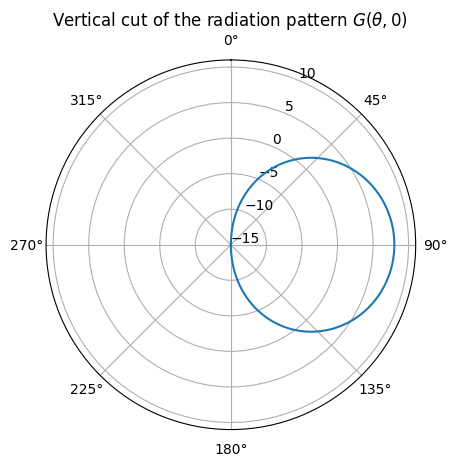

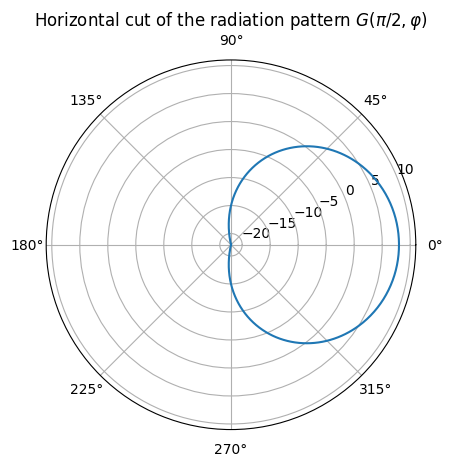

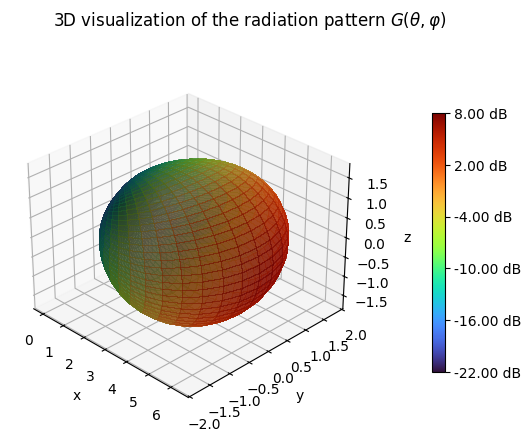

<Figure size 400x400 with 0 Axes>

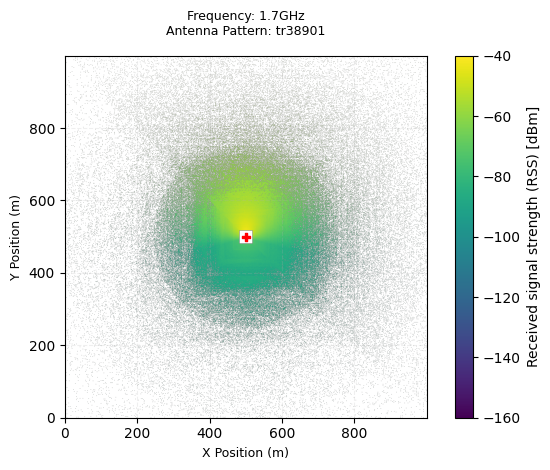

In [5]:
import numpy as np
from sionna.rt import load_scene, ITURadioMaterial, Transmitter, Receiver, PlanarArray, RadioMapSolver, PathSolver, InteractionType, Camera, AntennaPattern
import matplotlib.pyplot as plt
import pandas as pd
from collections import Counter

# Import scene from blender mitsuba export (.xml)
scene = load_scene("blender-assets/1km-field.xml")

tx_ant_pattern = "tr38901" # iso, dipole, hw_dipole, tr38901

# Add array for both Tx
scene.tx_array = PlanarArray(num_rows=1, 
                             num_cols=1,
                             vertical_spacing=0.5,
                             horizontal_spacing=0.5,
                             pattern=tx_ant_pattern,
                             polarization="V")

# Show antenna pattern properties
print(f"'{tx_ant_pattern}' Antenna Properties")
scene.tx_array.antenna_pattern.compute_gain()
scene.tx_array.antenna_pattern.show()

# Add frequency to scene
carrier_freq = 1.7e9 # In Hz
scene.frequency = carrier_freq

# Helper function to sync transmitter azimuth 0 degree with scene 0 degree
def compass_orientation(azimuth_deg, tilt_deg=0, roll_deg=0):

    # Sionna by default implement 0 degree Tx azimuth at X+ axis, -90 to achieve 0 degree at Y+ axis (North)
    sionna_azimuth = (90 - azimuth_deg) % 360

    # return radian
    return [
        float(np.deg2rad(sionna_azimuth)),
        float(np.deg2rad(tilt_deg)),
        float(np.deg2rad(roll_deg))
    ]

# Deploy Tx
tx_azimuth_deg = 0
tx_tilt_deg = 20

# Deploy Tx and Rx location
tx = Transmitter(
    "tx",
    position = [0, 0, 18], # x, y, z (location and height, in meter)
    orientation=compass_orientation(azimuth_deg=tx_azimuth_deg,tilt_deg=tx_tilt_deg), 
    power_dbm=18
)

# Deploy Rx
rx_azimuth_deg = 0
rx_tilt_deg = 0

rx = Receiver(
    "rx",
    [0, 500, 1.5],
    orientation=[
        float(np.deg2rad(rx_azimuth_deg)), float(np.deg2rad(rx_tilt_deg)), 0.0]
)

# Add Tx and Rx to the scene
scene.add(tx)
scene.add(rx)

# Plot 2D Radio Map
rm_solver = RadioMapSolver()

rm = rm_solver(
    scene,
    max_depth=10,
    samples_per_tx=10**7,
    cell_size=(1, 1),
    center=[0, 0, 0],
    size=[1000, 1000],
    orientation=[0, 0, 0]
)

plt.figure(figsize=(4, 4))
rm.show(metric="rss")
plt.title(
    f"Frequency: {carrier_freq/1e9}GHz\nAntenna Pattern: {tx_ant_pattern}",
    fontsize=9,
    pad=15
)
plt.xlabel("X Position (m)", fontsize=9)
plt.ylabel("Y Position (m)", fontsize=9)
plt.clim(-160, -40)
plt.grid(
    alpha=0.2,
    linestyle="--"
)
plt.tight_layout()
plt.show()

# Test

rss = rm.rss.numpy()[0]

# Extract non-zero values
rss_list = rss[rss != 0].flatten()

# Convert to dataframe
df = pd.DataFrame({
    "rss": rss_list
})

df["rss_dbm"] = 10 * np.log10(df["rss"]) +30

# Export
df.to_csv(
    f"export_rss_{tx_ant_pattern}.csv",
    index=False
)